# 12_时间序列分析方法-自回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/stock_data.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 股票记录按日期排序后再做前后切分；交易日序列按观测步长建模。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家聊聊时间序列分析法中的自回归模型\~

自回归模型是一种时间序列分析方法，简单易理解、预测性能好、适用于平稳数据、快速计算等等优点，受到大家的喜欢。

自回归模型，用于通过历史数据的线性组合来预测未来数据。简单来说，自回归模型认为当前时刻的值与之前时刻的值之间有某种关系，当前的值可以用前几个时刻的数据来预测。

### 怎么理解自回归？

**假设你有一个时间序列，比如某一天的温度：**

$t=1$天：25°C

$t=2$天：27°C

$t=3$天：26°C

$t=4$天：28°C

$t=5$天：？

现在你想预测第 5 天的温度。通过观察前三天的温度变化，你可能猜测未来的温度与之前几天的温度有某种规律。自回归模型就是利用这样的规律，根据之前的温度预测未来的温度。

### 自回归模型的数学表示

自回归模型的一般形式是：


$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t
$$


- $y_t$：当前时刻 $t$的值（例如，第 5 天的温度）
- $c$：常数项
- $\phi_1, \phi_2, ..., \phi_p$：自回归系数（用来权衡前几天数据的重要性）
- $\epsilon_t$：误差项（代表模型未解释的随机波动）

### 简单案例：预测股票价格

假设我们要预测某股票未来某天的价格，而我们有过去三天的收盘价格如下：

- 第 1 天：100 元
- 第 2 天：102 元
- 第 3 天：101 元
- 第 4 天：？

现在，我们想利用自回归模型来预测第 4 天的收盘价。

假设我们使用一个自回归模型的阶数为 2，即我们只考虑前两天的价格来预测第 4 天的价格。

自回归模型可以表示为：


$$
y_4 = c + \phi_1 y_3 + \phi_2 y_2
$$


这里：

- $y_4$是我们想要预测的第 4 天的价格
- $y_3 = 101$，这是第 3 天的价格
- $y_2 = 102$，这是第 2 天的价格
- $\phi_1$和 $\phi_2$是我们通过历史数据估计出来的参数

假设通过历史数据，我们估计出 $\phi_1 = 0.6$和 $\phi_2 = 0.3$，且常数项 $c = 1$。

我们把这些值代入公式：

$y_4 = 1 + 0.6 \times 101 + 0.3 \times 102$  
$y_4 = 1 + 60.6 + 30.6$  
$y_4 = 92.2 元$

因此，自回归模型预测第 4 天的价格大约为 92.2 元。

**自回归模型的核心思想是利用时间序列中之前的数据来预测未来的数据**。通过简单的线性回归方法，将之前的数据和某些权重结合，可以有效地预测短期的未来走势。

### 数学表达

为了更详细地理解自回归模型，我们通过以下步骤推导其形成和推理过程。

#### 1. 单变量线性回归的扩展

自回归模型实际上是多变量线性回归模型的一种特殊形式，其中自变量为过去时间点的观测值。以 $AR(1)$模型为例：


$$
y_t = c + \phi_1 y_{t-1} + \epsilon_t
$$


这个公式表示当前时刻的值 $y_t$是前一时刻 $y_{t-1}$的线性组合加上一个误差项。如果我们考虑两阶的自回归模型 $AR(2)$：


$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \epsilon_t
$$


这个模型表示当前值不仅依赖于前一个时刻的值，还依赖于前两个时刻的值。

#### 2. 向量化形式

为了简化理解，我们可以将 $AR(p)$模型表示为矩阵和向量的形式。以 $AR(2)$模型为例：


$$
\mathbf{y} = \mathbf{X} \boldsymbol{\phi} + \boldsymbol{\epsilon}
$$


其中：

- $\mathbf{y} = [y_3, y_4, ..., y_T]^T$是从第 3 时刻到第 $T$时刻的观测值向量
- $\mathbf{X} = \begin{bmatrix} 1 & y_2 & y_1 \\ 1 & y_3 & y_2 \\ \vdots & \vdots & \vdots \\ 1 & y_{T-1} & y_{T-2} \end{bmatrix}$是自回归模型的回归矩阵，第一列是常数项，后两列是过去两个时刻的观测值
- $\boldsymbol{\phi} = [c, \phi_1, \phi_2]^T$是我们要估计的参数向量
- $\boldsymbol{\epsilon} = [\epsilon_3, \epsilon_4, ..., \epsilon_T]^T$是误差向量

我们可以使用最小二乘法（OLS）来估计 $\boldsymbol{\phi}$，其估计公式为：


$$
\hat{\boldsymbol{\phi}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$


#### 3. 自相关与偏自相关

自回归模型的参数 $\phi_1, \phi_2, \dots, \phi_p$表示当前值与之前的观测值之间的关系。自相关函数（ACF）和偏自相关函数（PACF）是确定自回归模型阶数 $p$的工具。

- **自相关函数 (ACF)**：测量时间序列在不同滞后下的相关性。
- **偏自相关函数 (PACF)**：测量在排除了中间滞后影响后，时间序列在特定滞后下的相关性。

通过观察 PACF，当滞后阶的相关性明显下降时，可以帮助确定自回归模型的阶数 $p$。

#### 4. 自回归模型的估计

使用自回归模型的步骤通常如下：

1. **选择阶数** $p$：可以通过 PACF 确定，或使用信息准则如 AIC（Akaike 信息准则）和 BIC（贝叶斯信息准则）。
2. **估计参数** $\phi_1, \phi_2, \dots, \phi_p$：通常通过最小二乘法（OLS）或最大似然估计法（MLE）。
3. **进行预测**：基于已估计的参数来预测未来的值。

#### 5. 模型的稳定性

自回归模型的一个重要概念是**平稳性**。模型的平稳性取决于自回归系数 $\phi_1, \phi_2, \dots, \phi_p$的性质。如果系数满足特定条件，模型会趋向于稳定；否则，模型可能会发散。对于 $AR(1)$模型来说，平稳条件是 $|\phi_1| < 1$。

### 简单例子

再来一个简单容易理解的例子，假设我们有以下时间序列数据：$y_1 = 10, y_2 = 12, y_3 = 11$

使用 $AR(2)$模型来预测 $y_4$，其公式为：


$$
y_4 = c + \phi_1 y_3 + \phi_2 y_2 + \epsilon_4
$$


假设通过历史数据，我们得出参数 $c = 1, \phi_1 = 0.5, \phi_2 = 0.3$，并假设误差项 $\epsilon_4 \approx 0$。代入已有数据：

$y_4 = 1 + 0.5 \times 11 + 0.3 \times 12$  
$y_4 = 1 + 5.5 + 3.6 = 10.1$

因此，自回归模型预测第 4 时刻的值为 10.1。

下面是结合 **自回归 (AR)** 方法，基于Kaggle的股票市场数据来进行预测的一个案例。这个案例将使用自回归模型（AR 模型）对股票价格进行预测，并进行详细的分析和总结。

### 完整案例

案例：使用股票市场数据预测未来价格

我们将从 Kaggle 数据集中获取股票价格数据，使用 AR 模型对价格进行预测，并可视化原始数据、预测值、以及误差分析等。

公众号「深夜努力写Python」后台回复『数据集』即可获取\~

       Date   Open   High    Low  Close    Volume  Name
0  1/3/2006  39.69  41.22  38.79  40.91  24232729  AABA
1  1/4/2006  41.22  41.90  40.77  40.97  20553479  AABA
2  1/5/2006  40.93  41.73  40.85  41.53  12829610  AABA
3  1/6/2006  42.88  43.57  42.80  43.21  29422828  AABA
4  1/9/2006  43.10  43.66  42.82  43.42  16268338  AABA


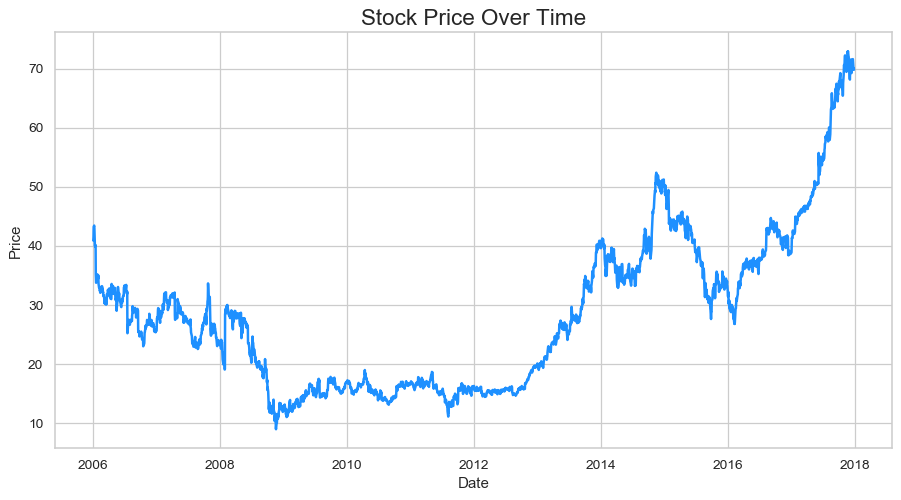

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set wil

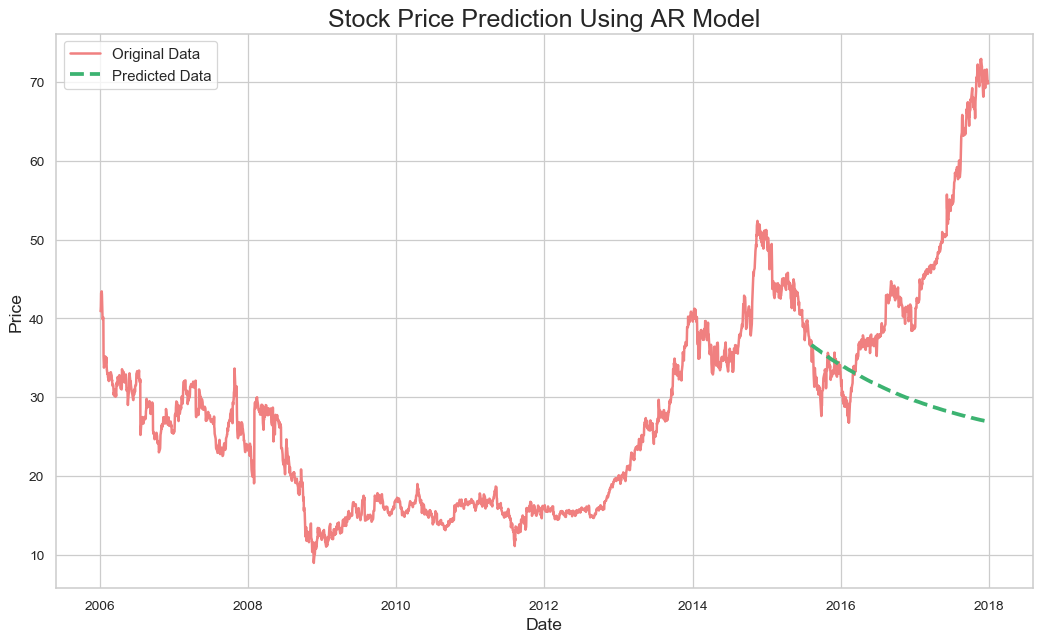

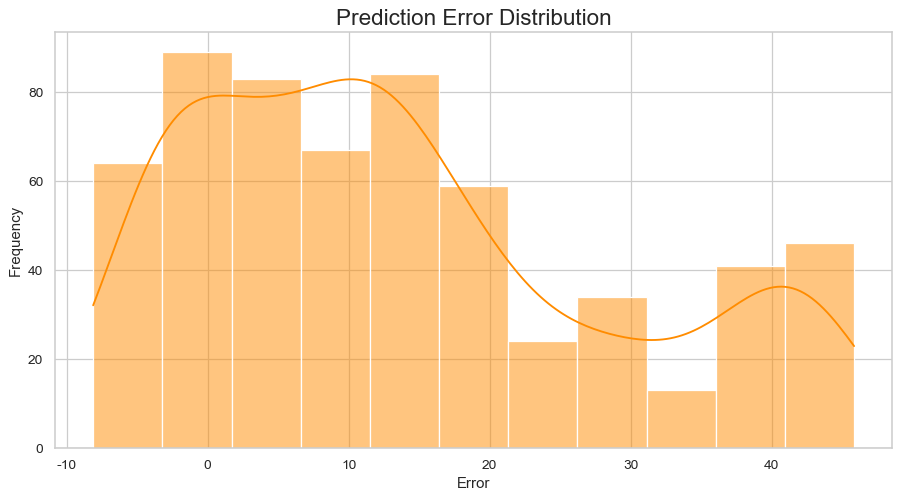

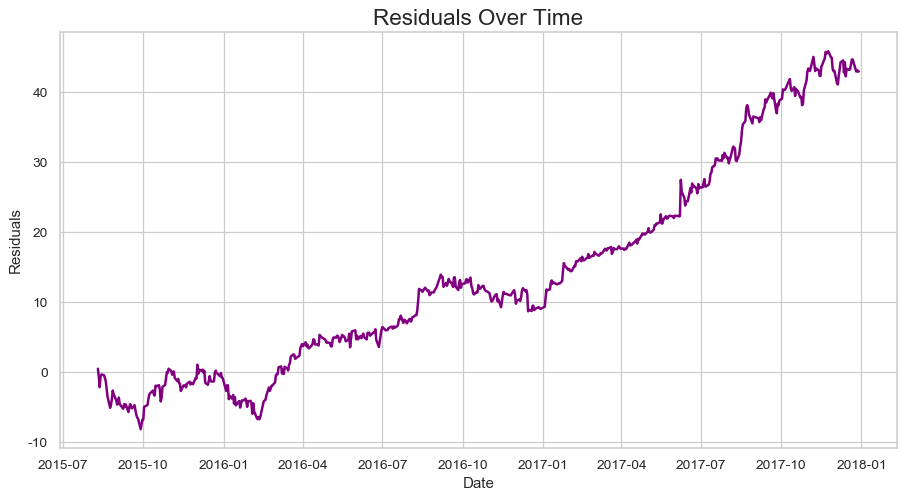

Mean Squared Error: 413.1219705752479


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

# 设置图形样式
plt.style.use('ggplot')
sns.set(style='whitegrid', palette='muted', color_codes=True)
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 加载数据 (假设我们从Kaggle导入了某个股票价格数据)
# 你可以替换为你的实际Kaggle数据路径
data = pd.read_csv(DATA_DIR / 'stock_data.csv')

# 查看数据
print(data.head())

# 选择时间和股票价格两列
# 假设我们有 "Date" 和 "Close" 列表示日期和收盘价
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').set_index('Date')

# 可视化原始数据
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], color='dodgerblue', lw=2)
plt.title('Stock Price Over Time', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()

# 自回归模型 (AR)
# 使用数据的前80%进行训练，后20%进行测试
train_size = int(len(data) * 0.8)
train, test = data['Close'][:train_size], data['Close'][train_size:]

# 训练AR模型
model = AutoReg(train, lags=5)  # 使用5阶的自回归
model_fit = model.fit()

# 进行预测
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# 绘制预测结果
plt.figure(figsize=(14, 8))
plt.plot(data.index, data['Close'], color='lightcoral', label='Original Data', lw=2)
plt.plot(test.index, predictions, color='mediumseagreen', linestyle='--', label='Predicted Data', lw=3)
plt.title('Stock Price Prediction Using AR Model', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

# 计算误差
errors = test.values - predictions[:len(test)]  # 只使用与 test 匹配的预测部分

# 绘制误差分布图
plt.figure(figsize=(12, 6))
sns.histplot(errors, kde=True, color='darkorange')
plt.title('Prediction Error Distribution', fontsize=18)
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 绘制残差图
plt.figure(figsize=(12, 6))
plt.plot(test.index, errors, color='purple', lw=2)
plt.title('Residuals Over Time', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True)
plt.show()

# 计算均方误差 (MSE)
mse = mean_squared_error(test, predictions)
print(f'Mean Squared Error: {mse}')

**1. 加载和处理数据**：我们从 Kaggle 数据集中加载股票价格数据，并选择日期 (`Date`) 和收盘价格 (`Close`) 列。

**2. 训练自回归模型 (AR)**：使用前 80% 的数据作为训练集，后 20% 的数据作为测试集。选择 5 阶自回归模型来进行训练。

**原始数据图**：展示股票价格的历史变化，蓝色线条展示了历史上的股票价格波动。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

**预测结果图**：比较原始数据和 AR 模型的预测值，绿色虚线显示了模型的预测值，红色实线表示真实数据，两者的对比展示了模型的预测能力。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

**误差分布图**：展示预测误差的分布，通过分布图，分析预测误差的分布情况，查看模型是否有偏差。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

**残差图**：展示模型预测与真实值之间的残差随时间的变化，展示模型预测与实际之间的残差，帮助判断模型的预测误差随时间的变化。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

**4. 误差计算**：使用均方误差（MSE）评估模型的预测性能。

### 自回归模型的优缺点及适用场景

#### 优点

1. **简单易理解**：自回归模型的数学公式简单易懂，它通过过去时间点的线性组合预测当前值。这种线性关系使其解释性强，容易进行参数估计。
2. **预测性能好**：对于具有较强自相关性的平稳时间序列，自回归模型往往表现优异，尤其在短期预测中。
3. **适用于平稳数据**：AR 模型在处理平稳时间序列时表现较好，特别是当数据的均值和方差在时间维度上保持稳定时，它能够有效捕捉数据的变化。
4. **快速计算**：相比复杂的非线性模型，自回归模型计算效率高，尤其是当阶数 $p$较小时。

#### 缺点

1. **局限于线性关系**：自回归模型假设当前值与过去的值具有线性关系，但许多实际问题中数据表现为非线性关系，AR 模型无法捕捉这些复杂动态。
2. **不适用于非平稳数据**：自回归模型适合处理平稳时间序列，当数据呈现趋势或季节性变化时，模型的表现会很差，需要对数据进行预处理（如差分、去趋势）。
3. **阶数选择复杂**：确定最佳阶数 $p$并不总是简单，虽然可以通过偏自相关函数 (PACF) 或信息准则 (AIC, BIC) 来确定，但在某些情况下阶数选择过高或过低都会导致模型性能下降。
4. **无法捕捉复杂的长周期或季节性变化**：如果时间序列中存在复杂的季节性或周期性特征，单纯的 AR 模型可能无法充分捕捉这些特征，需要引入更多特定模型（如 ARIMA 或 SARIMA）。

### 适用场景

1. **股票价格预测**：短期内股票价格的波动通常可以使用自回归模型进行预测。特别是在日内交易或短期波动上，AR 模型可以捕捉过去价格对未来价格的影响。
2. **气象数据分析**：当温度、气压等气象数据呈现一定的自相关性时，AR 模型可以用来预测短期天气趋势。
3. **经济数据分析**：GDP、通货膨胀率等经济数据，通常具有自相关性，可用 AR 模型进行短期预测。
4. **工业流程监控**：在一些自动化流程中，生产设备的传感器数据常常具有一定的自相关性，可以通过 AR 模型监控这些数据，预测可能的设备故障。